# telos vs STLCG++

Same semantics, timed. telos (eager PyTorch) against [STLCG++](https://github.com/UW-CTRL/stlcg-plus-plus)
(`stlcgpp 0.0.2`). RTX 3080 MAX-Q (16 GB), torch 2.8.0.
All measurements: `bench.py`; cached rows: `results/`.

In [1]:
import torch
from bench import parity, grid, sweep, speedups, plot, cached

gpu = torch.cuda.get_device_properties(0)
gpu.name, round(gpu.total_memory / 1e9, 1)

('NVIDIA GeForce RTX 3080 Laptop GPU', 16.8)

## Parity

Max |telos − STLCG++| over full robustness trajectories, on randomly generated formulas
(20 per depth ∈ {2, 4, 6}, all connectives) and traces (fresh per formula, T = 37).
`exact`: telos `Robustness` vs `approx_method='true'`. `lse`: telos `LSE(p=β)` vs `'logsumexp'`, `temperature=β`.

In [2]:
rows = parity()
worst = max(rows, key=lambda r: r['lse'])
print(f"{len(rows)} formulas   worst exact {max(r['exact'] for r in rows):.1e}"
      f"   worst lse {worst['lse']:.1e}  ({worst['formula']})")

60 formulas   worst exact 0.0e+00   worst lse 9.5e-07  (¬ ((⊤) 𝒰 (¬ (¬ ((⊤) 𝒰 (¬ (¬ ((⊤) 𝒰 (¬ (p ∧ p))))))))))


## Timing grid

telos vs `stlcgpp`, four formulas, T ∈ {64 … 4096} × B ∈ {1, 16, 64}, exact and lse, forward and forward+backward.
Geometric mean (min, max) of the per-cell speedup; `oom` lists (T, B) cells where `stlcgpp` runs out of memory on `U`.

In [3]:
s = speedups(cached('grid', lambda: grid()))
for k, v in s.items():
    print(k, tuple(round(x, 1) for x in v) if isinstance(v, tuple) else v)

('◇/□', 'fwd') (8.7, 2.5, 104.5)
('◇/□', 'fwd+bwd') (3.6, 1.3, 33.1)
('U', 'fwd') (85.6, 44.1, 268.1)
('U', 'fwd+bwd') (47.0, 20.1, 140.4)
cells 112
oom [(256, 64), (1024, 1), (1024, 16), (4096, 1)]


## Scaling

Dense T sweep, batch size 1, exact semantics, forward+backward. Lines end where an implementation
stops being measurable: a red x marks an out-of-memory point (placed by extrapolating the
line's established slope), CUTOFF marks a steady-state runtime past 10 minutes.

Four implementations. Hue is the tool, the darker shade its fast path:

- `telos (algebra-native)`: closed-form sequence reductions (cumulative scans for `◇`/`□`, a prefix-sharing
  span for unbounded `U`).
- `telos (algebra-agnostic fallback)`: the same reductions derived generically from the algebra's
  primitives via `scan`/`fold`; the path taken by algebras without closed forms.
- `STLCG++ (masked)`: the default; time-parallel over masked signal copies.
- `STLCG++ (recurrent)`: the original STLCG formulation; a step-by-step scan over time.
  Linear memory forward, but under backward the retained autograd graph grows with the
  rollout, so it too runs out of memory on unbounded `U`.

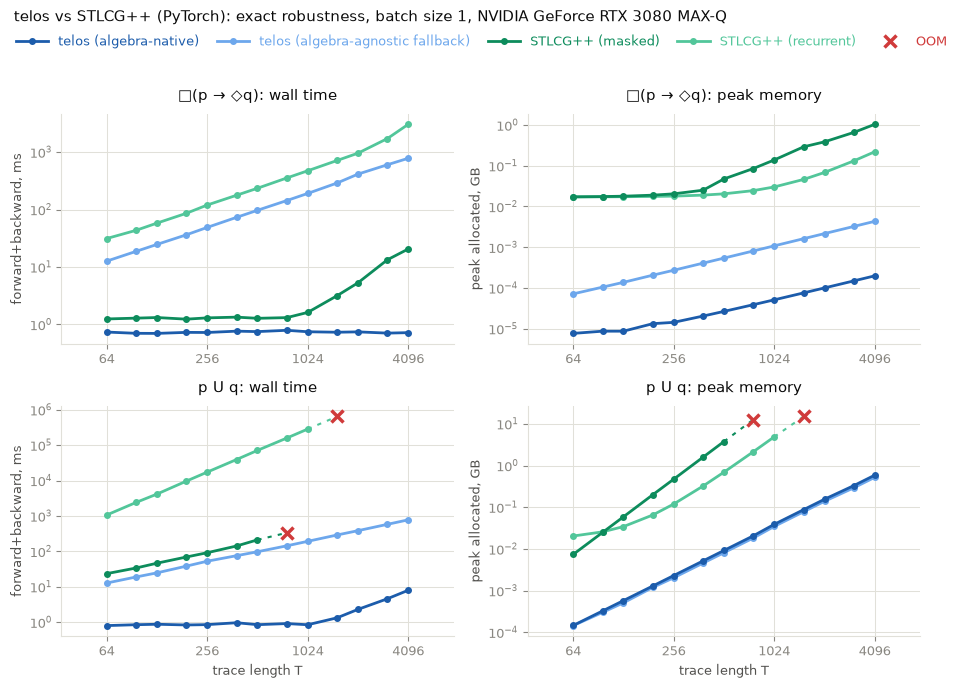

In [4]:
fig = plot(cached('sweep', lambda: sweep()),
           'telos vs STLCG++ (PyTorch): exact robustness, batch size 1, NVIDIA GeForce RTX 3080 MAX-Q',
           total_gb=gpu.total_memory / 1e9)
fig.savefig('scaling.png', dpi=200, bbox_inches='tight')

telos derives temporal operators from per-algebra sequence reductions: closed forms where
they exist (`◇`/`□` are O(T) scans, unbounded `U` an O(T²) span), a generic scan/fold
derivation otherwise. The masking construction is O(T²) and O(T³) respectively.